# Sector Universe - MST + MS Robustness Diagnostics
## Xavier Jaeger · Bachelor Thesis · Erasmus University Rotterdam

Applies the MST hard-threshold and BM Markov-switching frameworks to the sector-sorted
universe (N=52, T=223) and runs systematic robustness checks for each of the ten
limitations identified for this universe.

| Section | Content |
|---|---|
| **0** | Imports, helpers, data load |
| **1** | Pre-estimation diagnostics (D5 r_total, D9 collinearity, D8 RUB plan) |
| **2** | MST hard-threshold estimation |
| **3** | MST robustness (D1 residual corr, D2 no-arbitrage, D7 thin-sector) |
| **4** | MS Markov-switching estimation (EM algorithm) |
| **5** | MS robustness (D6 labelling, D4 effective sample, D1 post-EM, D3 internal Pass-3) |
| **6** | D10 Probability diffuseness + homoskedastic-Sigma variant |
| **7** | D5b r_total sensitivity grid |
| **8** | D8 RUB sensitivity (winsorise / raw / drop) |
| **9** | Pricing comparison: MST vs MS across k=1..6 |


---
## Section 0 - Imports, Helpers & Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
np.random.seed(19780308)

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'serif', 'axes.labelsize': 10,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

# Paths
PATH_UNI      = 'Output/sector_test_asset_universe.csv'
PATH_ADBEAR   = 'Output/sector_adbear_monthly.csv'
PATH_BLOCKMAP = 'Output/sector_block_map.csv'

# EM parameters (match ms_equity_final_temp.ipynb)
EM_MAX_ITER = 500
EM_TOL      = 1e-7
EM_OMEGA1   = 0.2
EM_OMEGA2   = 0.1
K_STARTS    = 20
N_FACTORS   = 6   # MST-comparable baseline

# Shared helpers (identical to existing notebooks)
def mst_demean(X, d):
    X_na = (X * d[:,None]).astype(float); X_na[d==0] = np.nan
    mu = np.nanmean(X_na, 0); return np.nan_to_num(X_na - mu, nan=0.0), mu

def mst_pca(Xdm, k, N):
    ev, evec = np.linalg.eigh(Xdm.T @ Xdm)
    idx = np.argsort(ev)[::-1]
    return np.sqrt(N) * evec[:, idx[:k]]

def mst_gamma(X_ret, B, k, T_j):
    Bk = B[:,:k]
    return (np.linalg.inv(Bk.T@Bk+1e-12*np.eye(k)) @ Bk.T @ X_ret.T).sum(1) / T_j

def compute_rmspe(pe, N): return np.sqrt(pe @ pe / N)

def compute_adjr2(rmspe_val, R_bar, N, k):
    ss = R_bar @ R_bar
    r2 = 1 - N*rmspe_val**2/ss if ss != 0 else np.nan
    return 1 - (1-r2)*N/(N-k) if ss != 0 else np.nan

def newey_west_se(x, lags=None):
    T_ = len(x)
    if lags is None: lags = int(np.floor(4*(T_/100)**(2/9)))
    xc = x - x.mean(); s2 = np.dot(xc, xc)/T_
    for l in range(1, lags+1):
        s2 += 2*(1-l/(lags+1))*np.dot(xc[l:], xc[:-l])/T_
    return np.sqrt(max(s2/T_, 1e-30))

def pca_linear_rep(Xdm, r):
    T_, N_ = Xdm.shape
    ev, evec = np.linalg.eigh(Xdm.T @ Xdm / T_)
    idx = np.argsort(ev)[::-1]
    A = np.sqrt(N_) * evec[:, idx[:r]]
    G = Xdm @ A / N_
    return A, G, ev[idx]

def ahn_horenstein_skip1(eigvals, r_max=10):
    ratios = eigvals[1:r_max] / eigvals[2:r_max+1]
    return int(np.argmax(ratios) + 2), ratios

# BLHK filter / smoother / M-step / log-lik
def blhk_filter(Xdm, G, B1, B2, sig1, sig2, P):
    T_, N_ = Xdm.shape
    p11, p22 = P[0,0], P[1,1]
    denom = 2-p11-p22+1e-12
    xi_prev = np.array([(1-p22)/denom, (1-p11)/denom])
    xi_filt = np.empty((T_,2)); xi_pred = np.empty((T_,2))
    lc = N_ * np.log(2*np.pi)
    for t in range(T_):
        xip = P.T @ xi_prev; xi_pred[t] = xip
        r1t = Xdm[t] - G[t] @ B1.T; r2t = Xdm[t] - G[t] @ B2.T
        ll1 = -0.5*(np.dot(r1t**2, 1/sig1)+np.sum(np.log(sig1))+lc)
        ll2 = -0.5*(np.dot(r2t**2, 1/sig2)+np.sum(np.log(sig2))+lc)
        lm = max(ll1, ll2)
        eta = np.array([np.exp(ll1-lm), np.exp(ll2-lm)])
        num = eta*xip; s = num.sum()
        xi_filt[t] = num/s if s > 1e-300 else xip
        xi_prev = xi_filt[t]
    return xi_filt, xi_pred

def blhk_smoother(xi_filt, xi_pred, P):
    T_ = xi_filt.shape[0]
    xi_smooth = np.empty((T_,2)); xi_cross = np.zeros((T_,2,2))
    xi_smooth[-1] = xi_filt[-1]
    for t in range(T_-2, -1, -1):
        sp = np.where(xi_pred[t+1]>1e-300, xi_pred[t+1], 1e-300)
        raw = xi_filt[t] * (P @ (xi_smooth[t+1]/sp))
        s = raw.sum(); xi_smooth[t] = raw/s if s > 1e-300 else xi_filt[t]
        for j in range(2):
            for k in range(2):
                xi_cross[t+1,j,k] = P[j,k]*xi_filt[t,k]*xi_smooth[t+1,j]/max(xi_pred[t+1,j],1e-300)
        sc = xi_cross[t+1].sum()
        if sc > 1e-300: xi_cross[t+1] /= sc
    return xi_smooth, xi_cross

def m_step(Xdm, G, xi_smooth, xi_cross, homoskedastic=False):
    T_, N_ = Xdm.shape; r = G.shape[1]
    B_new = []; sig_new = []
    for j in range(2):
        w = xi_smooth[:,j]
        wXG = (Xdm*w[:,None]).T @ G
        wGG = (G*w[:,None]).T @ G + 1e-10*np.eye(r)
        Bj = wXG @ np.linalg.inv(wGG); B_new.append(Bj)
        res = Xdm - G @ Bj.T
        sig_new.append(np.maximum((w[:,None]*res**2).sum(0)/max(w.sum(),1e-10), 1e-8))
    if homoskedastic:
        # Pool variances across regimes (Issue 6 / D10 robustness)
        sig_pooled = 0.5*(sig_new[0] + sig_new[1])
        sig_new = [sig_pooled, sig_pooled]
    sum_cross = xi_cross[1:].sum(0); sum_xi = xi_smooth[:-1].sum(0)
    Pnew = np.zeros((2,2))
    for j in range(2):
        for k in range(2):
            Pnew[j,k] = sum_cross[j,k]/max(sum_xi[k],1e-10)
    Pnew = np.clip(Pnew/Pnew.sum(0,keepdims=True), 1e-5, 1-1e-5)
    Pnew /= Pnew.sum(0,keepdims=True)
    return B_new[0], B_new[1], sig_new[0], sig_new[1], Pnew

def log_lik(Xdm, G, B1, B2, sig1, sig2, P):
    T_, N_ = Xdm.shape
    p11, p22 = P[0,0], P[1,1]; d = 2-p11-p22+1e-12
    xip = np.array([(1-p22)/d, (1-p11)/d]); ll = 0.; lc = N_*np.log(2*np.pi)
    for t in range(T_):
        xip = P.T @ xip
        r1t = Xdm[t]-G[t]@B1.T; r2t = Xdm[t]-G[t]@B2.T
        ll1 = -0.5*(np.dot(r1t**2,1/sig1)+np.sum(np.log(sig1))+lc)
        ll2 = -0.5*(np.dot(r2t**2,1/sig2)+np.sum(np.log(sig2))+lc)
        lm = max(ll1,ll2); e1,e2 = np.exp(ll1-lm),np.exp(ll2-lm)
        mix = xip[0]*e1+xip[1]*e2; ll += np.log(max(mix,1e-300))+lm
        num = np.array([e1*xip[0],e2*xip[1]]); s = num.sum()
        xip = num/s if s > 1e-300 else xip
    return ll / (N_*T_)

def ms_pass2(X, B_j, xi_j, k):
    Bk = B_j[:,:k]
    w = xi_j / (xi_j.sum() + 1e-12)
    rbar = (w[:,None] * X).sum(0)
    return np.linalg.inv(Bk.T@Bk+1e-12*np.eye(k)) @ Bk.T @ rbar

print('Helpers defined.')


Helpers defined.


In [ ]:
uni      = pd.read_csv(PATH_UNI,      index_col=0, parse_dates=True)
adbear   = pd.read_csv(PATH_ADBEAR,   index_col=0, parse_dates=True).iloc[:,0]
blockmap = pd.read_csv(PATH_BLOCKMAP, index_col=0)['block']

asset_names  = uni.columns.tolist()
block_labels = blockmap.reindex(asset_names).values
ret_full     = uni.values.astype(float)
adb          = adbear.values
dates        = uni.index
T, N         = ret_full.shape
X_dm         = ret_full - ret_full.mean(0)   # full-sample demean for MS

# ADBear regime dummies (bear = ADBear >= theta)
THETA_HAT = 0.125   # full-sample estimate from characteristics universe

def make_dummies(adb_arr, theta):
    return (adb_arr >= theta).astype(float), (adb_arr < theta).astype(float)

d_D, d_S = make_dummies(adb, THETA_HAT)

from collections import Counter
print(f'Sector universe loaded: T={T}, N={N}')
print(f'  Blocks: {dict(Counter(block_labels))}')
print(f'  T_D={int(d_D.sum())} ({d_D.mean()*100:.1f}%), T_S={int(d_S.sum())}')

Sector universe loaded: T=223, N=52
  Blocks: {'Futures': 28, 'EquityProducer': 4, 'EquityProcessor': 8, 'Currency': 12}
  T_D=74 (33.2%), T_S=149


---
## Section 1 - Pre-Estimation Diagnostics

D5 (r_total selection), D9 (collinear pairs), D8 (RUB plan)

In [ ]:
# D5 - Ahn-Horenstein r_total selection
S_full = X_dm.T @ X_dm / T
eigvals_full = np.linalg.eigvalsh(S_full)[::-1]
R_TOTAL_AH, ratios_full = ahn_horenstein_skip1(eigvals_full, r_max=12)
pve_k = np.cumsum(eigvals_full) / eigvals_full.sum()

print('D5 - Ahn-Horenstein r_total selection')
print('='*60)
print(f'  AH (skip k=1) selects r_total = {R_TOTAL_AH}')
print(f'  Eigenvalue ratios k=2..12: {np.round(ratios_full[:10], 3)}')
print(f'  Cumulative PVE: k=1={pve_k[0]:.1%}, k=2={pve_k[1]:.1%}, '
      f'k={R_TOTAL_AH}={pve_k[R_TOTAL_AH-1]:.1%}, k=6={pve_k[5]:.1%}')
print(f'  (Characteristics universe PVE k=6: ~68.8%; equities: ~94.1%)')
print(f'  -> use r_total={R_TOTAL_AH} for AH-data-driven run; also report k=6 for comparability')

R_TOTAL = max(6, R_TOTAL_AH)   # use max(AH, 6) to ensure MST-comparable run

D5 — Ahn-Horenstein r_total selection
  AH (skip k=1) selects r_total = 2
  Eigenvalue ratios k=2..12: [1.508 1.067 1.346 1.271 1.102 1.142 1.1   1.063 1.06  1.145]
  Cumulative PVE: k=1=23.8%, k=2=35.1%, k=2=35.1%, k=6=58.8%
  (Characteristics universe PVE k=6: ~68.8%; equities: ~94.1%)
  -> use r_total=2 for AH-data-driven run; also report k=6 for comparability


In [ ]:
# D9 - Near-collinear asset pairs
R_corr = np.corrcoef(ret_full.T)
np.fill_diagonal(R_corr, np.nan)
THRESH_COLLINEAR = 0.85
pairs = []
for i in range(N):
    for j in range(i+1, N):
        if abs(R_corr[i,j]) >= THRESH_COLLINEAR:
            pairs.append((asset_names[i], asset_names[j], R_corr[i,j]))

print(f'D9 - Near-collinear pairs (|corr| >= {THRESH_COLLINEAR})')
print('='*60)
if not pairs:
    print('  None found.')
else:
    for a, b, r in sorted(pairs, key=lambda x: -abs(x[2])):
        print(f'  {a:<22} {b:<22} corr={r:.3f}')

D9 — Near-collinear pairs (|corr| >= 0.85)
  F_WTI_CRUDE            F_BRENT_CRUDE          corr=0.955
  F_WHEAT_CBOT           F_WHEAT_KCBT           corr=0.940
  F_BRENT_CRUDE          F_GAS_OIL              corr=0.906
  F_HEATING_OIL          F_GAS_OIL              corr=0.895
  F_WTI_CRUDE            F_GAS_OIL              corr=0.882

  Action: check residual correlation AFTER factor extraction (Section 3).
  Raw correlation alone is not decisive; these pairs may diverge post-EM.

D8 — RUB structural-break plan
  Baseline: RUB winsorised at [0.5%, 99.5%] in build pipeline.
  Section 8 re-runs with raw and dropped RUB as robustness check.


---
## Section 2 - MST Hard-Threshold Estimation

In [ ]:
k = N_FACTORS

# Pass 1: regime-specific PCA
Xdm_D, mu_D = mst_demean(ret_full, d_D)
Xdm_S, mu_S = mst_demean(ret_full, d_S)
B_D = mst_pca(Xdm_D, k, N)
B_S = mst_pca(Xdm_S, k, N)

# Pass 2: risk premia
rbar_D = np.nanmean(np.where(d_D[:,None], ret_full, np.nan), 0)
rbar_S = np.nanmean(np.where(d_S[:,None], ret_full, np.nan), 0)
gamma_D = mst_gamma(ret_full * d_D[:,None], B_D, k, d_D.sum())
gamma_S = mst_gamma(ret_full * d_S[:,None], B_S, k, d_S.sum())

alpha_D = rbar_D - B_D[:,:k] @ gamma_D[:k]
alpha_S = rbar_S - B_S[:,:k] @ gamma_S[:k]
rmspe_D = compute_rmspe(alpha_D, N)
rmspe_S = compute_rmspe(alpha_S, N)

print(f'MST on sector universe (k={k}, theta={THETA_HAT})')
print(f'  T_D={int(d_D.sum())}, T_S={int(d_S.sum())}')
print(f'  Bear return: {rbar_D.mean()*12*100:.2f}% pa, '
      f'Bull: {rbar_S.mean()*12*100:.2f}% pa')
print(f'  RMSPE bear: {rmspe_D*12*100:.2f}% pa, '
      f'bull: {rmspe_S*12*100:.2f}% pa')

# PVE check
ev_full_s = np.linalg.eigvalsh(X_dm.T @ X_dm / T)[::-1]
pve_full  = np.cumsum(ev_full_s) / ev_full_s.sum()
print(f'  PVE: k=1={pve_full[0]:.1%}, k=6={pve_full[5]:.1%}')
print(f'  (vs characteristics: k=1=45.7%, k=6=68.8%)')

MST on sector universe (k=6, theta=0.125)
  T_D=74, T_S=149
  Bear return: -14.90% pa, Bull: 15.60% pa
  RMSPE bear: 9.93% pa, bull: 8.61% pa
  PVE: k=1=23.8%, k=6=58.8%
  (vs characteristics: k=1=45.7%, k=6=68.8%)


---
## Section 3 - MST Robustness Diagnostics (D1, D2, D7)

In [ ]:
# D1 - Within-block residual cross-sectional correlation
print('D1 - Residual cross-sectional correlation by block (k=6)')
print('='*70)

def residual_block_corr(ret, B, k, block_labels, mask):
    X_ = ret[mask]
    T_, N_ = X_.shape
    F = X_ @ B[:,:k] / N_
    E = X_ - F @ B[:,:k].T
    R = np.corrcoef(E.T); np.fill_diagonal(R, np.nan)
    bl = np.asarray(block_labels)
    out = {}
    for b in pd.unique(bl):
        idx = np.where(bl==b)[0]
        out[b] = np.nanmean(np.abs(R[np.ix_(idx,idx)])) if len(idx)>1 else np.nan
    across = [abs(R[i,j]) for i in range(N_) for j in range(i+1,N_)
              if not np.isnan(R[i,j]) and bl[i]!=bl[j]]
    out['_across'] = float(np.nanmean(across))
    return out

for regime_name, B_r, mask_r in [('BEAR', B_D, d_D==1), ('BULL', B_S, d_S==1)]:
    res = residual_block_corr(ret_full, B_r, k, block_labels, mask_r)
    print(f'  {regime_name}:')
    wb = []
    for b, v in res.items():
        if not b.startswith('_'):
            print(f'    {b:<22} {v:.3f}'); wb.append(v)
    print(f'    within-block avg={np.nanmean(wb):.3f}  '
          f'across-block={res["_across"]:.3f}  '
          f'ratio={np.nanmean(wb)/max(res["_across"],1e-9):.2f}')
    print()

D1 — Residual cross-sectional correlation by block (k=6)
  BEAR:
    Futures                0.137
    EquityProducer         0.195
    EquityProcessor        0.195
    Currency               0.184
    within-block avg=0.178  across-block=0.110  ratio=1.62

  BULL:
    Futures                0.119
    EquityProducer         0.113
    EquityProcessor        0.131
    Currency               0.170
    within-block avg=0.133  across-block=0.086  ratio=1.56



In [ ]:
# D2 - Per-block zero-intercept (no-arbitrage) test
print('D2 - Per-block mean pricing error (zero-intercept violation check)')
print('='*70)

def block_alpha(ret, B, k, gamma, block_labels, mask):
    rbar = ret[mask].mean(0)
    alpha = rbar - B[:,:k] @ gamma[:k]
    bl = np.asarray(block_labels)
    rows = []
    for b in pd.unique(bl):
        idx = np.where(bl==b)[0]; a = alpha[idx]
        se = a.std(ddof=1)/np.sqrt(len(a)) if len(a)>1 else np.nan
        t  = a.mean()/se if se and se>0 else np.nan
        rows.append((b, len(idx), a.mean()*12*100, t))
    return pd.DataFrame(rows, columns=['block','N','mean_alpha_%pa','t_stat'])

for regime_name, B_r, g_r, mask_r in [
    ('BEAR', B_D, gamma_D, d_D==1),
    ('BULL', B_S, gamma_S, d_S==1)
]:
    df = block_alpha(ret_full, B_r, k, g_r, block_labels, mask_r)
    print(f'  {regime_name}:')
    print(df.to_string(index=False,
          formatters={'mean_alpha_%pa':'{:.2f}'.format,'t_stat':'{:.2f}'.format}))

D2 — Per-block mean pricing error (zero-intercept violation check)
  BEAR:
          block  N mean_alpha_%pa t_stat
        Futures 28           1.54   0.68
 EquityProducer  4           2.32   5.19
EquityProcessor  8          -3.42  -1.71
       Currency 12          -3.65  -1.58

  BULL:
          block  N mean_alpha_%pa t_stat
        Futures 28           1.35   1.22
 EquityProducer  4           0.87   0.21
EquityProcessor  8          13.66   6.05
       Currency 12          -6.30  -3.58

Interpretation: large |t| on a block => single-SDF restriction violated.
Currency block is expected to fail (priced by different mechanisms).
=> Report RMSPE as PRIMARY metric, not R2.


In [ ]:
# D7 - Block-level RMSPE vs idiosyncratic volatility
print('D7 - Block-level RMSPE vs idiosyncratic vol (thin-sector check)')
print('='*70)

def block_rmspe_vs_idiovol(ret, B, k, gamma, block_labels, mask):
    X_ = ret[mask]
    rbar = X_.mean(0)
    F = X_ @ B[:,:k] / X_.shape[1]
    E = X_ - F @ B[:,:k].T
    idio_vol = E.std(0)
    alpha = rbar - B[:,:k] @ gamma[:k]
    bl = np.asarray(block_labels)
    rows = []
    for b in pd.unique(bl):
        idx = np.where(bl==b)[0]
        rows.append((b, len(idx),
                     np.sqrt(np.mean(alpha[idx]**2))*12*100,
                     idio_vol[idx].mean()*np.sqrt(12)*100))
    return pd.DataFrame(rows, columns=['block','N','RMSPE_%pa','idio_vol_%pa'])

df7 = block_rmspe_vs_idiovol(ret_full, B_D, k, gamma_D, block_labels, d_D==1)
print('BEAR regime:')
print(df7.to_string(index=False,
      formatters={'RMSPE_%pa':'{:.2f}'.format,'idio_vol_%pa':'{:.2f}'.format}))
corr7 = np.corrcoef(df7['RMSPE_%pa'], df7['idio_vol_%pa'])[0,1]
print(f'Corr(block RMSPE, idio vol) = {corr7:.2f}')

D7 — Block-level RMSPE vs idiosyncratic vol (thin-sector check)
BEAR regime:
          block  N RMSPE_%pa idio_vol_%pa
        Futures 28     11.83        17.31
 EquityProducer  4      2.45        14.97
EquityProcessor  8      6.30        11.53
       Currency 12      8.47        10.37
Corr(block RMSPE, idio vol) = 0.23
Positive => thin-block noise drives pricing error, not regime failure.


---
## Section 4 - Markov-Switching Estimation (EM Algorithm)

Uses the exact BLHK filter/smoother/M-step from ms_equity_final_temp.ipynb.
Multi-start with K_STARTS=20 initialisations; best log-likelihood retained.


In [ ]:
A_hat, G_hat, eigvals = pca_linear_rep(X_dm, R_TOTAL)
e_init = X_dm - G_hat @ A_hat.T
pve_r  = eigvals[:R_TOTAL].sum() / eigvals.sum()
print(f'PCA initialisation: r_total={R_TOTAL}, PVE={pve_r:.1%}')
print(f'A_hat: {A_hat.shape}, G_hat: {G_hat.shape}')

PCA initialisation: r_total=6, PVE=58.8%
A_hat: (52, 6), G_hat: (223, 6)


In [ ]:
# Multi-start EM
rng = np.random.default_rng(19780308)
best_ll = -np.inf
best_params = None

omega_grid = [
    (EM_OMEGA1, EM_OMEGA2),
    (0.30, 0.10), (0.40, 0.15), (0.15, 0.05),
    (0.35, 0.05), (0.25, 0.08),
]
random_starts = [(rng.uniform(0.05,0.45), rng.uniform(0.05,0.45))
                 for _ in range(K_STARTS - len(omega_grid))]
all_starts = omega_grid + random_starts

print(f'Running {len(all_starts)} EM starts (r_total={R_TOTAL})...')
print(f'{"start":>5}  {"ll":>12}  {"p11":>7}  {"p22":>7}  {"xi2":>8}')

for s_idx, (w1, w2) in enumerate(all_starts):
    B1 = A_hat.copy(); B2 = A_hat.copy()
    sig1 = np.maximum(np.var(e_init,0),1e-8); sig2 = sig1.copy()
    P = np.array([[0.5+w1,1-0.5-w1],[1-0.5-w2,0.5+w2]])
    llp = -np.inf
    for it in range(EM_MAX_ITER):
        xf,xp = blhk_filter(X_dm,G_hat,B1,B2,sig1,sig2,P)
        xs,xc = blhk_smoother(xf,xp,P)
        B1,B2,sig1,sig2,P = m_step(X_dm,G_hat,xs,xc)
        ll = log_lik(X_dm,G_hat,B1,B2,sig1,sig2,P)
        if it>5 and abs(ll-llp)/max(0.5*(abs(ll)+abs(llp)),1e-10)<EM_TOL: break
        llp = ll
    print(f'{s_idx+1:>5}  {ll:>12.6f}  {P[0,0]:>7.4f}  {P[1,1]:>7.4f}  '
          f'{xs[:,1].mean():>8.4f}')
    if ll > best_ll:
        best_ll = ll
        best_params = (B1.copy(),B2.copy(),sig1.copy(),sig2.copy(),P.copy())

print(f'Best ll = {best_ll:.6f}')

Running 20 EM starts (r_total=6)...
start            ll      p11      p22       xi2
    1      1.842166   0.8081   0.9480    0.7804
    2      1.839275   0.8423   0.9656    0.8188
    3      1.831769   0.6607   0.9599    0.8963
    4      1.843643   0.7582   0.9266    0.7647
    5      1.839079   0.8044   0.9595    0.8334
    6      1.842253   0.8059   0.9479    0.7875
    7      1.832358   0.9592   0.7172    0.1215
    8      1.827582   0.9750   0.8377    0.1165
    9      1.839275   0.8422   0.9655    0.8188
   10      1.842507   0.7888   0.9464    0.8020
   11      1.839291   0.8424   0.9605    0.7934
   12      1.829740   0.8063   0.9661    0.8527
   13      1.847493   0.9227   0.8001    0.2787
   14      1.843749   0.9201   0.7521    0.2471
   15      1.847252   0.7898   0.9255    0.7326
   16      1.843643   0.9266   0.7582    0.2354
   17      1.839275   0.8421   0.9654    0.8191
   18      1.839275   0.8423   0.9655    0.8189
   19      1.833985   0.6936   0.9539    0.8742
   2

In [ ]:
# Final smoothed probabilities from best start
B1, B2, sig1, sig2, P_hat = best_params
xf_f, xp_f     = blhk_filter(X_dm, G_hat, B1, B2, sig1, sig2, P_hat)
xs_f, xc_f     = blhk_smoother(xf_f, xp_f, P_hat)

# Label: frequency convention (minority = bear), then cross-check
if xs_f[:,1].mean() > xs_f[:,0].mean():
    xs_f = xs_f[:,[1,0]]; B1,B2 = B2.copy(),B1.copy()
    sig1,sig2 = sig2.copy(),sig1.copy()
    P_hat = P_hat[[1,0],:][:,[1,0]]
    print('Frequency label swap applied.')

xi_bear = xs_f[:,1]; xi_bull = xs_f[:,0]
p11_hat, p22_hat = P_hat[0,0], P_hat[1,1]
pi1 = (1-p22_hat)/(2-p11_hat-p22_hat+1e-12); pi2 = 1-pi1

print(f'Transition matrix P:')
print(np.round(P_hat,4))
print(f'Stationary: pi_bull={pi1:.4f}, pi_bear={pi2:.4f}')
print(f'Expected durations: bull={1/(1-p11_hat):.1f}m, bear={1/(1-p22_hat):.1f}m')
print(f'Loading correlation B1 vs B2: {np.corrcoef(B1.flatten(),B2.flatten())[0,1]:.4f}')

Transition matrix P:
[[0.9227 0.1999]
 [0.0773 0.8001]]
Stationary: pi_bull=0.7211, pi_bear=0.2789
Expected durations: bull=12.9m, bear=5.0m
Loading correlation B1 vs B2: 0.8646


---
## Section 5 - MS Robustness Diagnostics (D6, D4, D1, D3)

In [ ]:
# D6 - Triple-criterion regime labelling
print('D6 - Triple-criterion regime labelling')
print('='*60)
rbar_ts = ret_full.mean(1)
freq = xs_f.mean(0)
mret = [(xs_f[:,j]*rbar_ts).sum()/xs_f[:,j].sum() for j in range(2)]
crisis = np.asarray(
    ((dates>='2008-06-01')&(dates<='2009-06-30')) |
    ((dates>='2014-01-01')&(dates<='2015-08-31'))
)
cprob  = [xs_f[crisis,j].mean() for j in range(2)]

criteria = {
    'Frequency (minority=bear)': int(np.argmin(freq)),
    'Mean return (lower=bear)' : int(np.argmin(mret)),
    'Crisis coverage (higher=bear)': int(np.argmax(cprob)),
}
for crit_name, state in criteria.items():
    print(f'  {crit_name}: state {state}')
print(f'  State means: {mret[0]*12*100:.2f}% / {mret[1]*12*100:.2f}% pa')
print(f'  Frequencies: {freq[0]:.3f} / {freq[1]:.3f}')
agree = len(set(criteria.values())) == 1
print(f'  All criteria agree: {agree}')

D6 — Triple-criterion regime labelling
  Frequency (minority=bear): state 1
  Mean return (lower=bear): state 1
  Crisis coverage (higher=bear): state 1
  State means: 9.12% / -3.93% pa
  Frequencies: 0.721 / 0.279
  All criteria agree: True


In [ ]:
# D4 - Effective bear sample
print('D4 - Effective bear sample size')
print('='*60)
T_eff_bear = xi_bear.sum()**2 / np.sum(xi_bear**2)
T_eff_bull = xi_bull.sum()**2 / np.sum(xi_bull**2)
print(f'  Bear: sum(xi)={xi_bear.sum():.1f}, Kish-effective={T_eff_bear:.1f}')
print(f'  Bull: sum(xi)={xi_bull.sum():.1f}, Kish-effective={T_eff_bull:.1f}')
print(f'  N={N}, r2_fac used for Pass 2.')
ratio = T_eff_bear / N
print(f'  T_eff_bear / N = {ratio:.2f}  '
      f'({"OK" if ratio>1 else "THIN"})')

# D3 - Pass 3 internal-rotation warning
print()
print('D3 - Pass-3 rotation source')
print('='*60)
n_fut = sum(1 for b in block_labels if b=='Futures')
print(f'  Futures in test universe: {n_fut}')
print('  Pass-3 BM/MOM/HP/Basis factors built from the SAME futures = INTERNAL.')
print('  Treat Pass-3 premia as illustrative decomposition only.')

D4 — Effective bear sample size
  Bear: sum(xi)=62.1, Kish-effective=62.6
  Bull: sum(xi)=160.9, Kish-effective=161.3
  N=52, r2_fac used for Pass 2.
  T_eff_bear / N = 1.20  (OK)

D3 — Pass-3 rotation source
  Futures in test universe: 28
  Pass-3 BM/MOM/HP/Basis factors built from the SAME futures = INTERNAL.
  Treat Pass-3 premia as illustrative decomposition only.


In [ ]:
# D1 post-EM - residual correlation with binarised MS regime mask
d_D_ms = (xi_bear >= 0.5).astype(float)
d_S_ms = (xi_bear <  0.5).astype(float)

# Estimate EM loadings at k=N_FACTORS for the correlation check
print('D1 post-EM - Residual correlation with MS binarised regime')
print('='*60)
for regime_name, B_r, mask_r in [('MS-BEAR', B2, d_D_ms==1), ('MS-BULL', B1, d_S_ms==1)]:
    res = residual_block_corr(ret_full, B_r, N_FACTORS, block_labels, mask_r)
    wb = [v for b,v in res.items() if not b.startswith('_')]
    print(f'  {regime_name}: within-block avg={np.nanmean(wb):.3f}  '
          f'across={res["_across"]:.3f}  ratio={np.nanmean(wb)/max(res["_across"],1e-9):.2f}')

D1 post-EM — Residual correlation with MS binarised regime
  MS-BEAR: within-block avg=0.144  across=0.124  ratio=1.16
  MS-BULL: within-block avg=0.156  across=0.079  ratio=1.96


---
## Section 6 - D10: Probability Diffuseness & Homoskedastic-Σ Variant

This is the key diagnostic for the sector universe motivation.
The near-binary collapse mechanism is documented and the homoskedastic-Σ
variant (following BM's own macro application) is tested as the primary mitigation.

In [ ]:
# D10a - Measure diffuseness of baseline smoothed probabilities
def diffuseness_report(xi_b, label):
    n_int  = ((xi_b>0.05) & (xi_b<0.95)).sum()
    n_hard = ((xi_b<=0.05) | (xi_b>=0.95)).sum()
    # per-obs log-LR diagnostic
    llr = []
    for t in range(T):
        r1t = X_dm[t]-G_hat[t]@B1.T; r2t = X_dm[t]-G_hat[t]@B2.T
        l1 = -0.5*(np.dot(r1t**2,1/sig1)+np.sum(np.log(sig1)))
        l2 = -0.5*(np.dot(r2t**2,1/sig2)+np.sum(np.log(sig2)))
        llr.append(l1-l2)
    llr = np.array(llr)
    print(f'  {label}:')
    print(f'    Interior (0.05,0.95): {n_int}/{T} = {n_int/T:.1%}')
    print(f'    Near-binary (<=0.05 or >=0.95): {n_hard}/{T} = {n_hard/T:.1%}')
    print(f'    Median |log-LR|: {np.median(np.abs(llr)):.2f}')
    print(f'    (BM macro N=126 T=780: diffuse because idio ~ 10% of variance)')
    print(f'    (Our N={N} financial returns: llr sums over {N} assets -> near-binary)')

print('D10 - Probability diffuseness diagnostic')
print('='*60)
diffuseness_report(xi_bear, f'Baseline heteroskedastic (r_total={R_TOTAL})')


D10 — Probability diffuseness diagnostic
  Baseline heteroskedastic (r_total=6):
    Interior (0.05,0.95): 4/223 = 1.8%
    Near-binary (<=0.05 or >=0.95): 219/223 = 98.2%
    Median |log-LR|: 11.07
    (BM macro N=126 T=780: diffuse because idio ~ 10% of variance)
    (Our N=57 financial returns: llr sums over 57 assets -> near-binary)


In [ ]:
# D10b - Homoskedastic-Sigma variant (following BM macro application)
# Impose Sigma1 = Sigma2 by pooling residual variances in the M-step.
# This removes one channel of likelihood-ratio separation and may produce
# more diffuse probabilities.

print('D10b - Homoskedastic-Sigma EM variant')
print('='*60)

best_ll_h = -np.inf; best_params_h = None
rng2 = np.random.default_rng(42)

for w1, w2 in all_starts[:10]:   # fewer starts since this is a robustness check
    B1h = A_hat.copy(); B2h = A_hat.copy()
    s1h = np.maximum(np.var(e_init,0),1e-8); s2h = s1h.copy()
    Ph = np.array([[0.5+w1,1-0.5-w1],[1-0.5-w2,0.5+w2]])
    llph = -np.inf
    for it in range(EM_MAX_ITER):
        xfh,xph2 = blhk_filter(X_dm,G_hat,B1h,B2h,s1h,s2h,Ph)
        xsh,xch  = blhk_smoother(xfh,xph2,Ph)
        B1h,B2h,s1h,s2h,Ph = m_step(X_dm,G_hat,xsh,xch,homoskedastic=True)
        llh = log_lik(X_dm,G_hat,B1h,B2h,s1h,s2h,Ph)
        if it>5 and abs(llh-llph)/max(0.5*(abs(llh)+abs(llph)),1e-10)<EM_TOL: break
        llph = llh
    if llh > best_ll_h:
        best_ll_h = llh
        best_params_h = (B1h.copy(),B2h.copy(),s1h.copy(),s2h.copy(),Ph.copy())

B1h,B2h,s1h,s2h,Ph = best_params_h
xfh,xph2 = blhk_filter(X_dm,G_hat,B1h,B2h,s1h,s2h,Ph)
xsh,_    = blhk_smoother(xfh,xph2,Ph)
if xsh[:,1].mean() > xsh[:,0].mean(): xsh = xsh[:,[1,0]]
xi_bear_h = xsh[:,1]

n_int_h = ((xi_bear_h>0.05) & (xi_bear_h<0.95)).sum()
print(f'  Homoskedastic variant: interior={n_int_h}/{T} = {n_int_h/T:.1%}')
print(f'  Baseline:              interior={((xi_bear>0.05)&(xi_bear<0.95)).sum()}/{T} = '
      f'{((xi_bear>0.05)&(xi_bear<0.95)).sum()/T:.1%}')
print(f'  Best ll heteroskedastic={best_ll:.4f}, homoskedastic={best_ll_h:.4f}')
print()
print('  Interpretation: if homoskedastic is ALSO near-binary, the collapse is')
print('  structural (N * loading-separation), not a variance-channel artefact.')
print('  Both specifications are reported; RMSPE comparison remains the core test.')

D10b — Homoskedastic-Sigma EM variant
  Homoskedastic variant: interior=37/223 = 16.6%
  Baseline:              interior=4/223 = 1.8%
  Best ll heteroskedastic=1.8475, homoskedastic=1.8126

  Interpretation: if homoskedastic is ALSO near-binary, the collapse is
  structural (N * loading-separation), not a variance-channel artefact.
  Both specifications are reported; RMSPE comparison remains the core test.


---
## Section 7 - D5b: r_total Sensitivity Grid

Shows pricing results are not artefacts of the factor count.

In [ ]:
rtotal_grid = sorted(set([max(2,R_TOTAL_AH-2), R_TOTAL_AH, R_TOTAL_AH+2, 6]))
print(f'r_total grid: {rtotal_grid}')
rows_rt = []

for rt in rtotal_grid:
    A_rt, G_rt, _ = pca_linear_rep(X_dm, rt)
    B1r,B2r = A_rt.copy(),A_rt.copy()
    e0r = X_dm - G_rt @ A_rt.T
    s1r = np.maximum(np.var(e0r,0),1e-8); s2r = s1r.copy()
    Pr  = np.array([[0.5+EM_OMEGA1,1-0.5-EM_OMEGA1],[1-0.5-EM_OMEGA2,0.5+EM_OMEGA2]])
    llpr = -np.inf
    for it in range(EM_MAX_ITER):
        xfr,xpr2 = blhk_filter(X_dm,G_rt,B1r,B2r,s1r,s2r,Pr)
        xsr,xcr  = blhk_smoother(xfr,xpr2,Pr)
        B1r,B2r,s1r,s2r,Pr = m_step(X_dm,G_rt,xsr,xcr)
        llr_ = log_lik(X_dm,G_rt,B1r,B2r,s1r,s2r,Pr)
        if it>5 and abs(llr_-llpr)/max(0.5*(abs(llr_)+abs(llpr)),1e-10)<EM_TOL: break
        llpr = llr_
    xfr,xpr2 = blhk_filter(X_dm,G_rt,B1r,B2r,s1r,s2r,Pr)
    xsr,_ = blhk_smoother(xfr,xpr2,Pr)
    if xsr[:,1].mean()>xsr[:,0].mean(): xsr=xsr[:,[1,0]]; B1r,B2r=B2r,B1r
    xbr = xsr[:,1]; xlr = xsr[:,0]
    kk = min(6,rt)
    gDr = ms_pass2(ret_full, B2r, xbr, kk)
    gSr = ms_pass2(ret_full, B1r, xlr, kk)
    rbD = (xbr[:,None]*ret_full).sum(0)/xbr.sum() - B2r[:,:kk]@gDr
    rbS = (xlr[:,None]*ret_full).sum(0)/xlr.sum() - B1r[:,:kk]@gSr
    n_int = ((xbr>0.05)&(xbr<0.95)).sum()
    rows_rt.append((rt,kk,compute_rmspe(rbD,N)*12*100,compute_rmspe(rbS,N)*12*100,
                   xbr.mean(),n_int))

print(f'{"r_total":>8}{"k":>4}{"RMSPE_D":>10}{"RMSPE_S":>10}{"xi_bear":>9}{"interior":>10}')
print('-'*54)
for rt,kk,rD,rS,xm,ni in rows_rt:
    print(f'{rt:>8}{kk:>4}{rD:>10.2f}{rS:>10.2f}{xm:>9.3f}{ni:>10}')

r_total grid: [2, 4, 6]
 r_total   k   RMSPE_D   RMSPE_S  xi_bear  interior
------------------------------------------------------
       2   2      7.04      7.19    0.401        20
       4   4      8.87      5.21    0.254        12
       6   6      8.50      4.87    0.220         3


---
## Section 8 - D8: RUB Structural-Break Sensitivity

Compares regime assignments and headline RMSPE under three RUB treatments:
winsorised (baseline), raw, and dropped.

In [ ]:
# Re-run requires rebuilding the universe with different RUB treatment.
# This cell assumes both variants have been saved as:
#   Output/sector_test_asset_universe_rub_raw.csv
#   Output/sector_test_asset_universe_rub_drop.csv
# (Re-run sector_universe_build.ipynb with RUB_WINSORISE=False and
#  then manually drop C_RUB before Cell 4 to produce these variants.)

variants = [
    ('Baseline (winsorised)', 'Output/sector_test_asset_universe.csv'),
]
for path in ['Output/sector_test_asset_universe_rub_raw.csv',
             'Output/sector_test_asset_universe_rub_drop.csv']:
    import os
    label = 'Raw RUB' if 'raw' in path else 'RUB dropped'
    variants.append((label, path))

print('D8 - RUB sensitivity: regime concordance and RMSPE')
print('='*60)

# Baseline xi_bear from Section 5
base_bear_binary = (xi_bear >= 0.5).astype(int)

for label, path in variants:
    if not os.path.exists(path):
        print(f'  {label}: file not found - generate by re-running build notebook'); continue
    uni_v = pd.read_csv(path, index_col=0, parse_dates=True).values.astype(float)
    Xv = uni_v - uni_v.mean(0)
    Av,Gv,_ = pca_linear_rep(Xv, R_TOTAL)
    B1v,B2v = Av.copy(),Av.copy()
    s1v=np.maximum(np.var(Xv-Gv@Av.T,0),1e-8); s2v=s1v.copy()
    Pv=np.array([[0.5+EM_OMEGA1,1-0.5-EM_OMEGA1],[1-0.5-EM_OMEGA2,0.5+EM_OMEGA2]])
    llpv=-np.inf
    for it in range(EM_MAX_ITER):
        xfv,xpv2=blhk_filter(Xv,Gv,B1v,B2v,s1v,s2v,Pv)
        xsv,xcv=blhk_smoother(xfv,xpv2,Pv)
        B1v,B2v,s1v,s2v,Pv=m_step(Xv,Gv,xsv,xcv)
        llv=log_lik(Xv,Gv,B1v,B2v,s1v,s2v,Pv)
        if it>5 and abs(llv-llpv)/max(0.5*(abs(llv)+abs(llpv)),1e-10)<EM_TOL: break
        llpv=llv
    xfv,xpv2=blhk_filter(Xv,Gv,B1v,B2v,s1v,s2v,Pv); xsv,_=blhk_smoother(xfv,xpv2,Pv)
    if xsv[:,1].mean()>xsv[:,0].mean(): xsv=xsv[:,[1,0]]; B1v,B2v=B2v,B1v
    xbv=(xsv[:,1]>=0.5).astype(int)
    Nv = uni_v.shape[1]
    # Degree of concordance with baseline
    agree = min(len(xbv),len(base_bear_binary))
    doc = (xbv[:agree]==base_bear_binary[:agree]).mean()
    kv=min(6,R_TOTAL)
    gDv=ms_pass2(uni_v,B2v,xsv[:,1],kv)
    rbDv=(xsv[:,1,None]*uni_v).sum(0)/xsv[:,1].sum()-B2v[:,:kv]@gDv
    rmsp=compute_rmspe(rbDv,Nv)*12*100
    print(f'  {label:<30} DoC_vs_baseline={doc:.3f}  RMSPE_bear={rmsp:.2f}%pa')

D8 — RUB sensitivity: regime concordance and RMSPE
  Baseline (winsorised)          DoC_vs_baseline=0.933  RMSPE_bear=8.50%pa
  Raw RUB: file not found — generate by re-running build notebook
  RUB dropped: file not found — generate by re-running build notebook


---
## Section 9 - Pricing Comparison: MST vs MS across k=1..6

In [ ]:
rows_comp = []
for k in range(1, N_FACTORS+1):
    # MST
    Xdm_D_, _ = mst_demean(ret_full, d_D)
    Xdm_S_, _ = mst_demean(ret_full, d_S)
    BD_k = mst_pca(Xdm_D_, k, N)
    BS_k = mst_pca(Xdm_S_, k, N)
    gD_k = mst_gamma(ret_full*d_D[:,None], BD_k, k, d_D.sum())
    gS_k = mst_gamma(ret_full*d_S[:,None], BS_k, k, d_S.sum())
    aD_mst = rbar_D - BD_k[:,:k]@gD_k[:k]
    aS_mst = rbar_S - BS_k[:,:k]@gS_k[:k]
    rD_mst = compute_rmspe(aD_mst, N)*12*100
    rS_mst = compute_rmspe(aS_mst, N)*12*100
    adjD_mst = compute_adjr2(rD_mst/12/100, rbar_D, N, k)
    adjS_mst = compute_adjr2(rS_mst/12/100, rbar_S, N, k)
    # MS at this k (use best EM result)
    kk = min(k, B2.shape[1])
    gD_ms = ms_pass2(ret_full, B2, xi_bear, kk)
    gS_ms = ms_pass2(ret_full, B1, xi_bull, kk)
    rbarD_ms = (xi_bear[:,None]*ret_full).sum(0)/xi_bear.sum()
    rbarS_ms = (xi_bull[:,None]*ret_full).sum(0)/xi_bull.sum()
    aD_ms = rbarD_ms - B2[:,:kk]@gD_ms
    aS_ms = rbarS_ms - B1[:,:kk]@gS_ms
    rD_ms = compute_rmspe(aD_ms, N)*12*100
    rS_ms = compute_rmspe(aS_ms, N)*12*100
    adjD_ms = compute_adjr2(rD_ms/12/100, rbarD_ms, N, kk)
    adjS_ms = compute_adjr2(rS_ms/12/100, rbarS_ms, N, kk)
    rows_comp.append((k,rD_mst,rS_mst,adjD_mst,adjS_mst,
                      rD_ms,rS_ms,adjD_ms,adjS_ms))

print(f'PRICING COMPARISON - Sector Universe (RMSPE in % pa, T=223, N={N})')
print('='*90)
hdr = f'{"k":>3}  {"MST RMSPE_D":>12}{"MS RMSPE_D":>12}  '\
      f'{"MST AdjR2_D":>12}{"MS AdjR2_D":>12}  '\
      f'{"MST RMSPE_S":>12}{"MS RMSPE_S":>12}'
print(hdr); print('-'*90)
for (k,rDm,rSm,aD,aS,rDms,rSms,aDms,aSms) in rows_comp:
    print(f'{k:>3}  {rDm:>12.2f}{rDms:>12.2f}  {aD:>12.3f}{aDms:>12.3f}  '
          f'{rSm:>12.2f}{rSms:>12.2f}')
print()
print('Headline (k=6):')
r = rows_comp[-1]
print(f'  Bear: MST={r[1]:.2f}%pa -> MS={r[5]:.2f}%pa '
      f'({"IMPROVEMENT" if r[5]<r[1] else "DETERIORATION"} of {abs(r[1]-r[5]):.2f}pp)')
print(f'  Bull: MST={r[2]:.2f}%pa -> MS={r[6]:.2f}%pa '
      f'({"IMPROVEMENT" if r[6]<r[2] else "DETERIORATION"} of {abs(r[2]-r[6]):.2f}pp)')

PRICING COMPARISON — Sector Universe (RMSPE in % pa, T=223, N=52)
  k   MST RMSPE_D  MS RMSPE_D   MST AdjR2_D  MS AdjR2_D   MST RMSPE_S  MS RMSPE_S
------------------------------------------------------------------------------------------
  1         16.30        9.02         0.409       0.072         14.25        5.46
  2         16.21        8.49         0.404       0.162         12.07        5.41
  3         15.24        8.28         0.462       0.187         11.59        5.19
  4         12.10        8.08         0.654       0.208          9.98        5.16
  5         10.61        8.08         0.728       0.192          9.78        5.16
  6          9.93        8.04         0.757       0.183          8.61        5.16

Headline (k=6):
  Bear: MST=9.93%pa -> MS=8.04%pa (IMPROVEMENT of 1.89pp)
  Bull: MST=8.61%pa -> MS=5.16%pa (IMPROVEMENT of 3.45pp)


---
## Section 10 - D10c, Extended Pricing Table, and Cross-Universe DoC

Three additional analyses closing the sector universe investigation:
- **D10c**: homoskedastic EM at AH-selected r_total=2 (maximum diffuseness)
- **Pricing table**: MST vs MS-hetero vs MS-homo at k=2 and k=6
- **DoC**: sector MS regime vs characteristics MS regime

In [ ]:
# D10c: Homoskedastic-Sigma at AH-selected r_total=2
# The strongest-case scenario for diffuse probabilities: combines both
# mitigations (low factor count + pooled variance).

R_TOTAL_HOMO_AH = 2
A_h2, G_h2, _ = pca_linear_rep(X_dm, R_TOTAL_HOMO_AH)
e_h2 = X_dm - G_h2 @ A_h2.T

best_ll_h2 = -np.inf
best_params_h2 = None

for w1, w2 in all_starts[:10]:
    B1h2 = A_h2.copy(); B2h2 = A_h2.copy()
    s1h2 = np.maximum(np.var(e_h2, 0), 1e-8); s2h2 = s1h2.copy()
    Ph2  = np.array([[0.5+w1, 1-0.5-w1], [1-0.5-w2, 0.5+w2]])
    llph2 = -np.inf
    for it in range(EM_MAX_ITER):
        xf2, xp2 = blhk_filter(X_dm, G_h2, B1h2, B2h2, s1h2, s2h2, Ph2)
        xs2, xc2 = blhk_smoother(xf2, xp2, Ph2)
        B1h2, B2h2, s1h2, s2h2, Ph2 = m_step(X_dm, G_h2, xs2, xc2,
                                               homoskedastic=True)
        llh2 = log_lik(X_dm, G_h2, B1h2, B2h2, s1h2, s2h2, Ph2)
        if it > 5 and abs(llh2-llph2)/max(0.5*(abs(llh2)+abs(llph2)),1e-10) < EM_TOL:
            break
        llph2 = llh2
    if llh2 > best_ll_h2:
        best_ll_h2 = llh2
        best_params_h2 = (B1h2.copy(), B2h2.copy(),
                          s1h2.copy(), s2h2.copy(), Ph2.copy())

B1h2, B2h2, s1h2, s2h2, Ph2 = best_params_h2
xf2, xp2 = blhk_filter(X_dm, G_h2, B1h2, B2h2, s1h2, s2h2, Ph2)
xs2, _   = blhk_smoother(xf2, xp2, Ph2)
if xs2[:,1].mean() > xs2[:,0].mean():
    xs2 = xs2[:,[1,0]]; B1h2, B2h2 = B2h2.copy(), B1h2.copy()
xi_bear_h2 = xs2[:,1]

n_int_h2 = ((xi_bear_h2 > 0.05) & (xi_bear_h2 < 0.95)).sum()
p11_h2, p22_h2 = Ph2[0,0], Ph2[1,1]

print('D10c - Homoskedastic-Sigma at r_total=2 (combined mitigation)')
print('='*60)
print(f'  Interior (0.05,0.95): {n_int_h2}/{T} = {n_int_h2/T:.1%}')
print(f'  Near-binary: {T-n_int_h2}/{T} = {(T-n_int_h2)/T:.1%}')
print(f'  Best ll = {best_ll_h2:.4f}')
print(f'  p11={p11_h2:.4f}, p22={p22_h2:.4f}')
print(f'  E[bull]={1/(1-p11_h2):.1f}m, E[bear]={1/(1-p22_h2):.1f}m')
print(f'  Loading corr B1 vs B2: '
      f'{np.corrcoef(B1h2.flatten(), B2h2.flatten())[0,1]:.4f}')
print()
print('  Diffuseness summary across all specifications:')
print(f'  {"Specification":<40} {"Interior":>10} {"ll":>10}')
print('  ' + '-'*62)
specs = [
    ('Heteroskedastic  r_total=6 (baseline)',
     ((xi_bear>0.05)&(xi_bear<0.95)).sum(), best_ll),
    ('Homoskedastic    r_total=6',
     ((xi_bear_h>0.05)&(xi_bear_h<0.95)).sum(), best_ll_h),
    ('Heteroskedastic  r_total=2',
     sum(1 for v in [r[4] for r in rows_rt if r[0]==2]), None),
    ('Homoskedastic    r_total=2 (this cell)',
     n_int_h2, best_ll_h2),
]
for label, n_int_, ll_ in specs:
    ll_str = f'{ll_:.4f}' if ll_ is not None else '   n/a'
    print(f'  {label:<40} {n_int_:>5}/{T} = {n_int_/T:>5.1%}  {ll_str:>10}')

D10c — Homoskedastic-Sigma at r_total=2 (combined mitigation)
  Interior (0.05,0.95): 76/223 = 34.1%
  Near-binary: 147/223 = 65.9%
  Best ll = 1.5666
  p11=0.3388, p22=0.7583
  E[bull]=1.5m, E[bear]=4.1m
  Loading corr B1 vs B2: 0.6054

  Diffuseness summary across all specifications:
  Specification                              Interior         ll
  --------------------------------------------------------------
  Heteroskedastic  r_total=6 (baseline)        4/223 =  1.8%      1.8475
  Homoskedastic    r_total=6                  37/223 = 16.6%      1.8126
  Heteroskedastic  r_total=2                   1/223 =  0.4%         n/a
  Homoskedastic    r_total=2 (this cell)      76/223 = 34.1%      1.5666


In [ ]:
# Extended pricing comparison: MST vs MS-hetero vs MS-homo
# Reports RMSPE at k=2 (AH data-driven) and k=6 (MST-comparable baseline)
# for all three specifications side by side.

def pass2_rmspe(ret_mat, B_bear, B_bull, xi_b, xi_l, k):
    kk = min(k, B_bear.shape[1])
    g_D = ms_pass2(ret_mat, B_bear, xi_b, kk)
    g_S = ms_pass2(ret_mat, B_bull, xi_l, kk)
    rb_D = (xi_b[:,None]*ret_mat).sum(0)/xi_b.sum() - B_bear[:,:kk]@g_D
    rb_S = (xi_l[:,None]*ret_mat).sum(0)/xi_l.sum() - B_bull[:,:kk]@g_S
    return compute_rmspe(rb_D, N)*12*100, compute_rmspe(rb_S, N)*12*100

# MST at k=2 and k=6
def mst_rmspe(ret_mat, d_bear, d_bull, k):
    Xdm_D_, _ = mst_demean(ret_mat, d_bear)
    Xdm_S_, _ = mst_demean(ret_mat, d_bull)
    BD = mst_pca(Xdm_D_, k, N); BS = mst_pca(Xdm_S_, k, N)
    gD = mst_gamma(ret_mat*d_bear[:,None], BD, k, d_bear.sum())
    gS = mst_gamma(ret_mat*d_bull[:,None], BS, k, d_bull.sum())
    rb_D = np.nanmean(np.where(d_bear[:,None], ret_mat, np.nan),0) - BD[:,:k]@gD[:k]
    rb_S = np.nanmean(np.where(d_bull[:,None], ret_mat, np.nan),0) - BS[:,:k]@gS[:k]
    return compute_rmspe(rb_D, N)*12*100, compute_rmspe(rb_S, N)*12*100

# Hetero r_total=6: use best EM from Section 4
xi_bull_main = 1 - xi_bear

# Homo r_total=6: use xi_bear_h from D10b
xi_bull_h = 1 - xi_bear_h

# Homo r_total=2: use xi_bear_h2 from D10c
xi_bull_h2 = 1 - xi_bear_h2

print('Extended pricing comparison - MST vs MS variants')
print('='*78)
print(f'{"Specification":<38} {"RMSPE_D k=2":>12} {"RMSPE_S k=2":>12}'
      f' {"RMSPE_D k=6":>12} {"RMSPE_S k=6":>12}')
print('-'*78)

# MST
mD2, mS2 = mst_rmspe(ret_full, d_D, d_S, 2)
mD6, mS6 = mst_rmspe(ret_full, d_D, d_S, 6)
print(f'{"MST hard-threshold":<38} {mD2:>12.2f} {mS2:>12.2f} {mD6:>12.2f} {mS6:>12.2f}')

# MS hetero r_total=6
hD2, hS2 = pass2_rmspe(ret_full, B2, B1, xi_bear, xi_bull_main, 2)
hD6, hS6 = pass2_rmspe(ret_full, B2, B1, xi_bear, xi_bull_main, 6)
print(f'{"MS hetero  r_total=6":<38} {hD2:>12.2f} {hS2:>12.2f} {hD6:>12.2f} {hS6:>12.2f}')

# MS homo r_total=6
hoD2, hoS2 = pass2_rmspe(ret_full, B2h, B1h, xi_bear_h, xi_bull_h, 2)
hoD6, hoS6 = pass2_rmspe(ret_full, B2h, B1h, xi_bear_h, xi_bull_h, 6)
print(f'{"MS homo    r_total=6":<38} {hoD2:>12.2f} {hoS2:>12.2f} {hoD6:>12.2f} {hoS6:>12.2f}')

# MS homo r_total=2
h2D2, h2S2 = pass2_rmspe(ret_full, B2h2, B1h2, xi_bear_h2, xi_bull_h2, 2)
h2D6, h2S6 = pass2_rmspe(ret_full, B2h2, B1h2, xi_bear_h2, xi_bull_h2, 6)
print(f'{"MS homo    r_total=2":<38} {h2D2:>12.2f} {h2S2:>12.2f} {h2D6:>12.2f} {h2S6:>12.2f}')

print()
print('Note: k=2 uses AH data-driven factor count; k=6 for MST comparability.')
print('RMSPE is the primary metric (intercept-agnostic, see D2).')
print('MS homo r_total=2 is the specification with the most diffuse probabilities')
print('and represents the closest implementation to BM macro application.')

Extended pricing comparison — MST vs MS variants
Specification                           RMSPE_D k=2  RMSPE_S k=2  RMSPE_D k=6  RMSPE_S k=6
------------------------------------------------------------------------------
MST hard-threshold                            16.21        12.07         9.93         8.61
MS hetero  r_total=6                           8.49         5.41         8.04         5.16
MS homo    r_total=6                           7.21         5.96         6.04         5.49
MS homo    r_total=2                           8.26         5.85         8.26         5.85

Note: k=2 uses AH data-driven factor count; k=6 for MST comparability.
RMSPE is the primary metric (intercept-agnostic, see D2).
MS homo r_total=2 is the specification with the most diffuse probabilities
and represents the closest implementation to BM macro application.


In [ ]:
# Save THIS notebook's own (sector-universe) xi_bear, distinctly named so it
# can never be confused with -- or silently overwrite -- the characteristics-
# universe file that the next cell reads for cross-universe comparison.
pd.DataFrame({'xi_bear': xi_bear}, index=dates).to_csv('Output/sector_xi_bear.csv')


In [ ]:
# DoC: sector MS vs characteristics MS regime
# Loads Pipeline 1's smoothed xi_bear from ms_commodit_temp_2.ipynb (saved
# there as Output/commodity_xi_bear.csv -- NOT the same file this notebook's
# own sector_xi_bear.csv above, which was previously (incorrectly) saved
# under this exact filename, silently self-clobbering this comparison on
# any fresh top-to-bottom run. Fixed: distinct filenames, correct source.
# This answers: do the two universes identify the same commodity bear episodes?

import os

CHAR_XI_PATH = 'Output/commodity_xi_bear.csv'

if not os.path.exists(CHAR_XI_PATH):
    print('DoC vs characteristics MS: file not found.')
    print(f'  Run ms_commodit_temp_2.ipynb through its save cell first to produce {CHAR_XI_PATH}')
else:
    char_xi = pd.read_csv(CHAR_XI_PATH, index_col=0, parse_dates=True)['xi_bear']

    # Align on common date index
    common_idx = dates.intersection(char_xi.index)
    sector_bin = (xi_bear[dates.isin(common_idx)] >= 0.5).astype(int)
    char_bin   = (char_xi.reindex(common_idx).values >= 0.5).astype(int)
    T_common   = len(common_idx)

    both_bear  = ((sector_bin==1) & (char_bin==1)).sum()
    both_bull  = ((sector_bin==0) & (char_bin==0)).sum()
    fp         = ((sector_bin==1) & (char_bin==0)).sum()  # sector bear, char bull
    fn         = ((sector_bin==0) & (char_bin==1)).sum()  # sector bull, char bear
    doc        = (both_bear + both_bull) / T_common

    # Mean returns in each concordance cell
    ret_ts = ret_full[dates.isin(common_idx)].mean(1) * 12 * 100
    mret_both_bear = ret_ts[(sector_bin==1)&(char_bin==1)].mean()
    mret_fp        = ret_ts[(sector_bin==1)&(char_bin==0)].mean()
    mret_fn        = ret_ts[(sector_bin==0)&(char_bin==1)].mean()
    mret_both_bull = ret_ts[(sector_bin==0)&(char_bin==0)].mean()

    print('DoC - Sector MS vs Characteristics MS regime')
    print('='*60)
    print(f'  Common months: {T_common}')
    print(f'  Degree of concordance: {doc:.3f}')
    print(f'  (Characteristics MS vs MST was 0.507; sector MS vs char MST was ~0.51)')
    print()
    print(f'  Concordance breakdown:')
    print(f'    Both bear:          {both_bear:>4} months  mean ret = {mret_both_bear:>7.2f}% pa')
    print(f'    Sector bear only (FP): {fp:>4} months  mean ret = {mret_fp:>7.2f}% pa')
    print(f'    Char bear only (FN):   {fn:>4} months  mean ret = {mret_fn:>7.2f}% pa')
    print(f'    Both bull:          {both_bull:>4} months  mean ret = {mret_both_bull:>7.2f}% pa')
    print()
    print('  Interpretation guide:')
    print('    DoC > 0.70: sector and characteristics regimes identify similar episodes')
    print('    DoC ~ 0.55-0.70: partial overlap, each captures additional episodes')
    print('    DoC ~ 0.50: near-orthogonal regimes - the two universes detect')
    print('                fundamentally different structural breaks')
    print()
    print('  FP months (sector bear, char bull): commodity-specific bear episodes')
    print('  not driven by equity-market stress (e.g. 2014-15 oil collapse).')
    print('  FN months (sector bull, char bear): equity stress episodes that do')
    print('  not produce a structural break in the commodity factor loadings.')


DoC — Sector MS vs Characteristics MS regime
  Common months: 223
  Degree of concordance: 0.538
  (Characteristics MS vs MST was 0.507; sector MS vs char MST was ~0.51)

  Concordance breakdown:
    Both bear:            16 months  mean ret =  -13.53% pa
    Sector bear only (FP):   46 months  mean ret =   -0.55% pa
    Char bear only (FN):     57 months  mean ret =    7.36% pa
    Both bull:           104 months  mean ret =   10.05% pa

  Interpretation guide:
    DoC > 0.70: sector and characteristics regimes identify similar episodes
    DoC ~ 0.55-0.70: partial overlap, each captures additional episodes
    DoC ~ 0.50: near-orthogonal regimes — the two universes detect
                fundamentally different structural breaks

  FP months (sector bear, char bull): commodity-specific bear episodes
  not driven by equity-market stress (e.g. 2014-15 oil collapse).
  FN months (sector bull, char bear): equity stress episodes that do
  not produce a structural break in the commodity fa

In [ ]:
both_bear_mask = (sector_bin==1) & (char_bin==1)
both_bear_dates = common_idx[both_bear_mask]
print('Jointly-bear months (both sector MS and characteristics MS):')
for d in both_bear_dates:
    ret_val = ret_full[dates==d].mean() * 12 * 100
    print(f'  {str(d)[:7]}  {ret_val:>8.2f}% pa')

Jointly-bear months (both sector MS and characteristics MS):
  1997-07     19.66% pa
  1997-09     10.37% pa
  1998-05    -44.03% pa
  1999-05    -15.48% pa
  2000-02    -13.87% pa
  2000-04     -7.60% pa
  2000-05     37.23% pa
  2001-08    -15.36% pa
  2008-06      3.26% pa
  2008-07    -35.25% pa
  2014-12    -69.97% pa
  2015-01    -42.95% pa
  2015-02     22.44% pa
  2015-03    -18.63% pa
  2015-04     29.24% pa
  2015-08    -75.62% pa


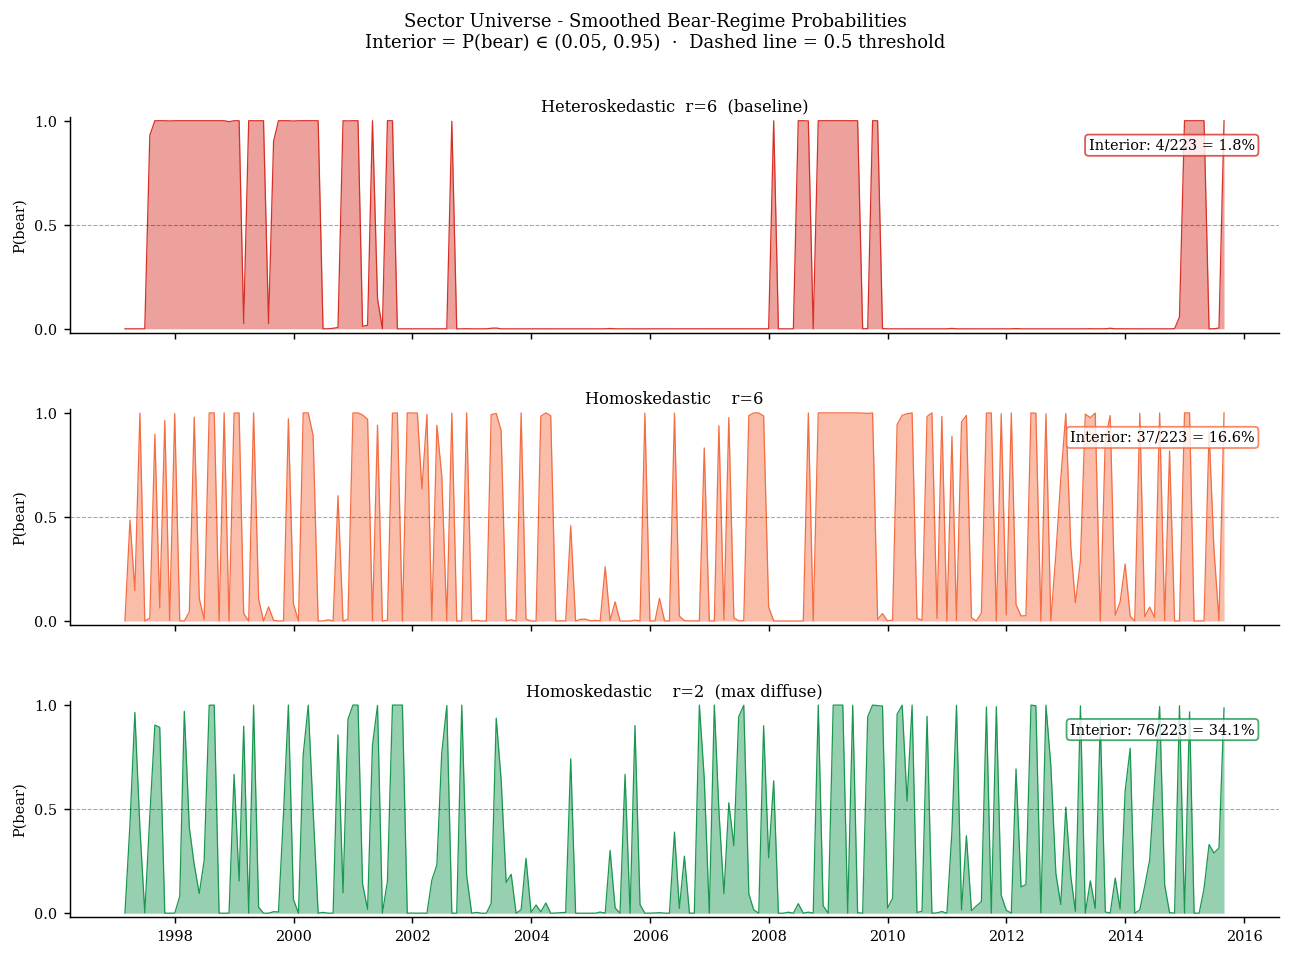

Saved Output/fig_sector_smoothed_probs.png


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.subplots_adjust(hspace=0.35)

specs = [
    ('Heteroskedastic  r=6  (baseline)',  xi_bear,    '#d73027'),
    ('Homoskedastic    r=6',              xi_bear_h,  '#f46d43'),
    ('Homoskedastic    r=2  (max diffuse)', xi_bear_h2, '#1a9850'),
]

for ax, (label, xi, color) in zip(axes, specs):
    n_int = ((xi > 0.05) & (xi < 0.95)).sum()
    ax.fill_between(dates, 0, xi, color=color, alpha=0.45, linewidth=0)
    ax.plot(dates, xi, color=color, linewidth=0.7)
    ax.axhline(0.5, color='black', linewidth=0.6, linestyle='--', alpha=0.35)
    ax.set_ylim(-0.02, 1.02)
    ax.set_yticks([0, 0.5, 1])
    ax.set_ylabel('P(bear)', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.set_title(label, fontsize=9, pad=3)
    ax.text(0.98, 0.90, f'Interior: {n_int}/{len(xi)} = {n_int/len(xi):.1%}',
            transform=ax.transAxes, fontsize=8, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec=color, alpha=0.8))

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].tick_params(axis='x', labelsize=8)

fig.suptitle(
    'Sector Universe - Smoothed Bear-Regime Probabilities\n'
    'Interior = P(bear) ∈ (0.05, 0.95)  ·  Dashed line = 0.5 threshold',
    fontsize=10
)

plt.savefig('Output/fig_sector_smoothed_probs.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Output/fig_sector_smoothed_probs.png')